# Exploratory Data Analysis (EDA)

## 1. Temporal Integrity Verification

This section loads the processed dataset and verifies temporal continuity by checking for missing hourly timestamps. Any detected gaps indicate that reindexing or imputation is required during preprocessing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot configuration
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (15, 6)

# Load dataset
df = pd.read_csv('../data/processed/merge_ds.csv')
df['dt_iso'] = pd.to_datetime(df['dt_iso'], utc=True)
df = df.set_index('dt_iso').sort_index()

# Verify temporal continuity by comparing against an ideal hourly range
full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='h')
missing_timestamps = full_range.difference(df.index)

print(f"Total rows: {len(df)}")
print(f"Missing timestamps: {len(missing_timestamps)}")

if len(missing_timestamps) > 0:
    print("WARNING: Temporal gaps detected. Reindexing/imputation required in preprocessing.py")
    print(missing_timestamps[:5])
else:
    print("OK: Time series is continuous (no gaps).")

Total rows: 17544
Missing timestamps: 0
OK: Time series is continuous (no gaps).


## 2. Missing Values Analysis

This section identifies and visualizes missing values across the dataset. A heatmap provides a quick overview of null locations over time. Additionally, the `rain_1h` column is analyzed under the assumption that NaN values represent zero precipitation.

rain_1h    13812
dtype: int64


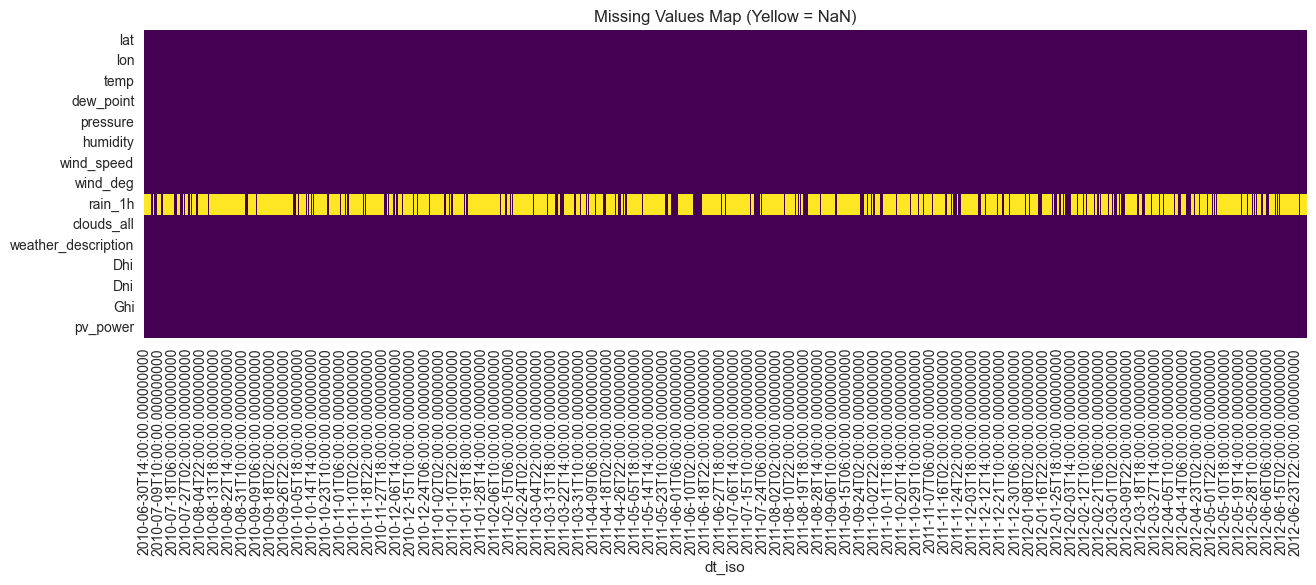

Rain statistics (with fillna 0):
count    17544.000000
mean         0.124873
std          0.397985
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          6.730000
Name: rain_1h_filled, dtype: float64


In [2]:
# Check for null values
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0])

# Visualize missing value locations across features
plt.figure(figsize=(15, 4))
sns.heatmap(df.isnull().T, cbar=False, cmap='viridis')
plt.title("Missing Values Map (Yellow = NaN)")
plt.show()

# Rain column analysis: NaN often indicates 0 precipitation
df['rain_1h_filled'] = df['rain_1h'].fillna(0)
print("Rain statistics (with fillna 0):")
print(df['rain_1h_filled'].describe())

## 3. Target Analysis (PV Power) and Daily Seasonality

This section compares PV power output between a winter week and a summer week to highlight seasonal and daily cyclical patterns. Since the dataset is from the Southern Hemisphere, July represents winter and January represents summer. Additionally, nighttime PV output is verified by checking mean power when Global Horizontal Irradiance (GHI) equals zero.

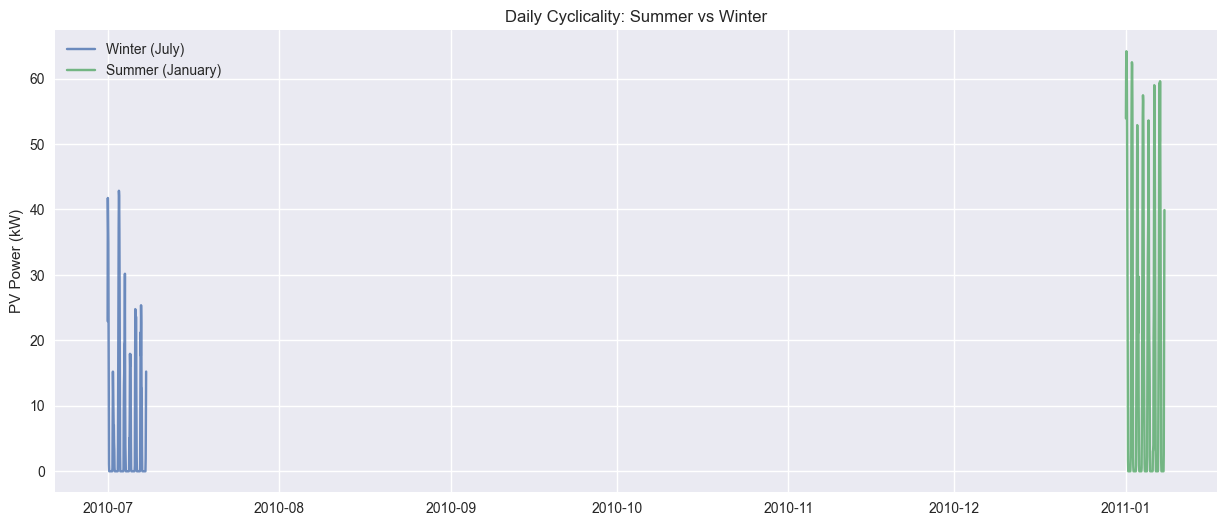

Mean PV Power when Irradiance (GHI) is 0: 0.0530


In [3]:
# Compare weekly patterns between winter and summer (Southern Hemisphere: July = Winter, January = Summer)
subset_winter = df['2010-07-01':'2010-07-07']
subset_summer = df['2011-01-01':'2011-01-07']

plt.figure(figsize=(15, 6))
plt.plot(subset_winter.index, subset_winter['pv_power'], label='Winter (July)', alpha=0.8)
plt.plot(subset_summer.index, subset_summer['pv_power'], label='Summer (January)', alpha=0.8)
plt.title("Daily Cyclicality: Summer vs Winter")
plt.ylabel("PV Power (kW)")
plt.legend()
plt.show()

# Verify PV output during nighttime (when GHI = 0)
night_values = df[df['Ghi'] == 0]['pv_power']
print(f"Mean PV Power when Irradiance (GHI) is 0: {night_values.mean():.4f}")

The PV power peak is approximately 40,000 in winter and 70,000 in summer, indicating the series is non-stationary. Therefore, data normalization or temporal features representing seasonality (e.g., sine/cosine encoding of the year) are required.
If nighttime PV power is not exactly zero (due to sensor noise), it should be forced to zero in preprocessing.py. Physically, when GHI equals zero, PV output must be zero. This correction also helps the network converge faster.

## 4. Feature Importance (Correlations)

This section examines feature correlations using a Pearson correlation matrix to identify relationships between key meteorological variables and PV power output. A scatter plot of GHI vs PV Power is also included to visualize the expected near-linear physical relationship between solar irradiance and photovoltaic generation.

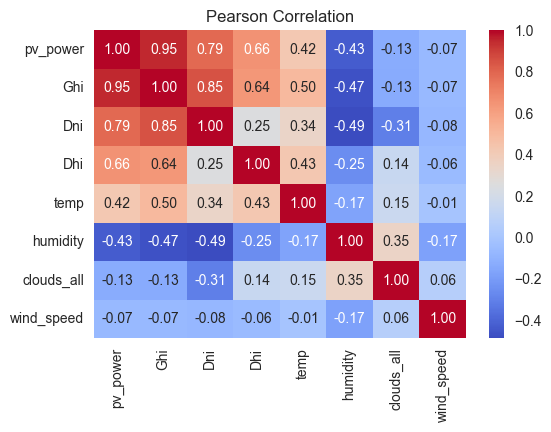

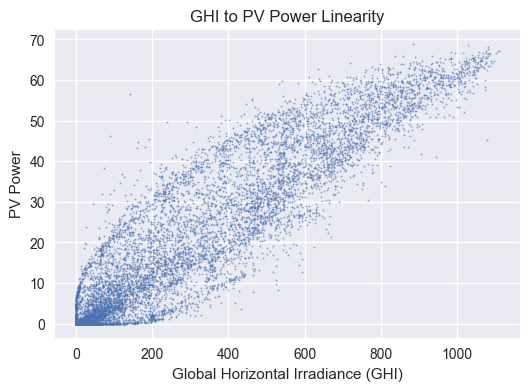

In [4]:
# Correlation matrix for key features
cols_to_check = ['pv_power', 'Ghi', 'Dni', 'Dhi', 'temp', 'humidity', 'clouds_all', 'wind_speed']
corr = df[cols_to_check].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Pearson Correlation")
plt.show()

# Scatter plot: GHI vs PV Power (physical relationship)
plt.figure(figsize=(6, 4))
plt.scatter(df['Ghi'], df['pv_power'], alpha=0.5, s=1)
plt.xlabel("Global Horizontal Irradiance (GHI)")
plt.ylabel("PV Power")
plt.title("GHI to PV Power Linearity")
plt.show()

GHI exhibits a very high correlation (>0.9) with PV power, confirming it as the primary driver of photovoltaic output.
In the scatter plot, data points with high GHI but zero PV power are likely anomalies or outliers (e.g., panels offline for maintenance).

## 5. Autocorrelation Analysis (Lookback Window)

This section computes the autocorrelation of the PV power target variable across multiple hourly lags. The analysis helps determine how far back in time the model should look to capture temporal dependencies, revealing daily and weekly cyclical patterns in power generation.

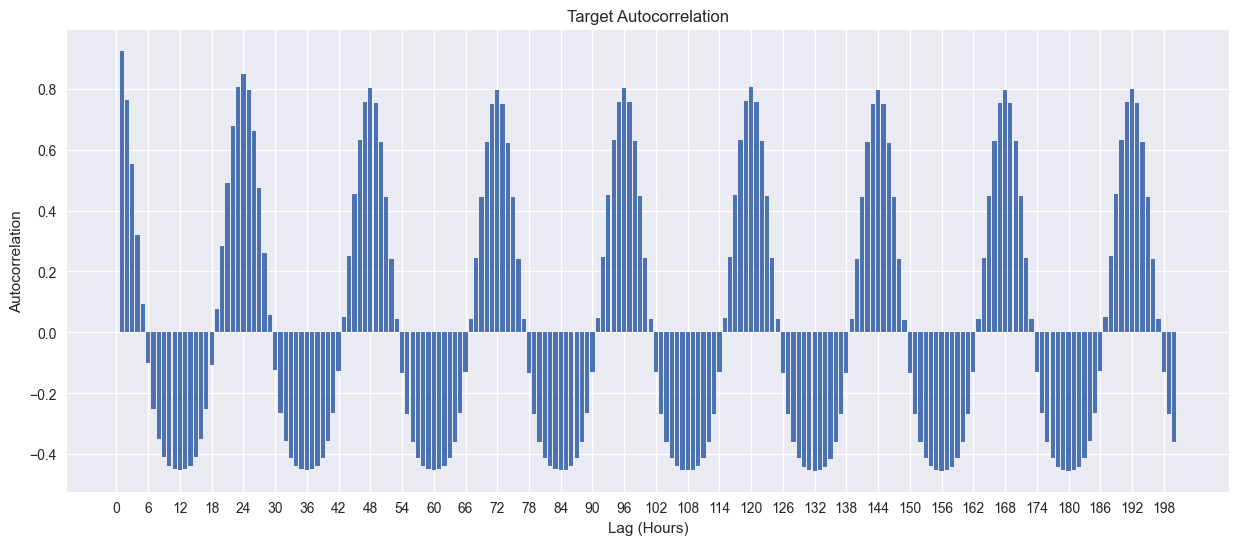

In [5]:
plt.figure(figsize=(15, 6))

# Compute autocorrelation for the first 400 lags
lags = 200
corr_vals = [df['pv_power'].autocorr(lag=i) for i in range(1, lags+1)]

plt.bar(range(1, lags+1), corr_vals)
plt.xlabel("Lag (Hours)")
plt.ylabel("Autocorrelation")
plt.title("Target Autocorrelation")
plt.xticks(np.arange(0, lags+1, 6))
plt.show()

This analysis provides guidance on selecting appropriate sliding window (LOOKBACK) values. The LOOKBACK should be at least 24 hours, with 48 or 72 hours being preferable, to effectively capture the observed autocorrelation patterns.